In [1]:
import geopandas as gpd
import pandas as pd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import Point, LineString
from shapely.ops import linemerge

### Mision 1

In [2]:
# cordenadas en formato (latitud, longitud)
origen_a1 = (-33.4996, -70.6156)         
destino_chena = (-33.593891, -70.742777)

epsg_metrico = 32719

vel_caminata = 5000 / 60   # 5 km/h
vel_metro = 30000 / 60     # 30 km/h

espera_metro = 8

In [3]:
ruta_estaciones = "datos_geoespaciales/Metro 2020/Estaciones_2020/Estaciones_2020.shp"
ruta_lineas = "datos_geoespaciales/Metro 2020/Lineas_2020/Lineas_2020.shp"

estaciones = gpd.read_file(ruta_estaciones)
lineas = gpd.read_file(ruta_lineas)

print("CRS estaciones:", estaciones.crs)
print("CRS líneas:", lineas.crs)

# WGS84 para coordenadas/visualización
estaciones_wgs = estaciones.to_crs(epsg=4326)
lineas_wgs = lineas.to_crs(epsg=4326)

# métricas para medir distancias reales
estaciones_m = estaciones.to_crs(epsg=epsg_metrico)
lineas_m = lineas.to_crs(epsg=epsg_metrico)

display(estaciones_wgs.head())
display(lineas_wgs.head())

CRS estaciones: EPSG:32719
CRS líneas: EPSG:4326


,OBJECTID,ID_LINEA,LINEA,ESTACION,NOMBRE,POINT_X,POINT_Y,geometry
0,2,2,L2,EL PARRON,El Parrón,345717.3664,6.289105e+06,POINT (-70.66142 -33.52651)
1,3,5,L5,CUMMING,Cumming,344899.1198,6.298782e+06,POINT (-70.66855 -33.43916)
2,4,5,L5,QUINTA NORMAL,Quinta Normal,343809.1081,6.298628e+06,POINT (-70.6803 -33.44044)
3,5,7,L4A,SAN RAMON,San Ramón,346685.4133,6.287624e+06,POINT (-70.64318 -33.54122)
4,6,7,L4A,SANTA ROSA,Santa Rosa,348282.5816,6.287378e+06,POINT (-70.63409 -33.54245)


,OBJECTID,ID_LINEA,LINEA,LENGTH,Shape_Leng,Shape_Le_1,geometry
0,3,2,L2,18315.942,20087.016072,1301.975352,"LINESTRING (-70.66142 -33.52651, -70.66325 -33..."
1,4,2,L2,18315.942,20087.016072,1057.384032,"LINESTRING (-70.65881 -33.51723, -70.66138 -33..."
2,5,2,L2,18315.942,20087.016072,802.130950,"LINESTRING (-70.65682 -33.5102, -70.65865 -33...."
3,6,2,L2,18315.942,20087.016072,599.761286,"LINESTRING (-70.65315 -33.49734, -70.65346 -33..."
4,7,2,L2,18315.942,20087.016072,866.182956,"LINESTRING (-70.65465 -33.5026, -70.65679 -33...."


In [4]:
punto_origen = gpd.GeoSeries(
    [Point(origen_a1[1], origen_a1[0])],
    crs="EPSG:4326"
)

punto_destino = gpd.GeoSeries(
    [Point(destino_chena[1], destino_chena[0])],
    crs="EPSG:4326"
)

origen_m = punto_origen.to_crs(epsg=epsg_metrico).iloc[0]
destino_m = punto_destino.to_crs(epsg=epsg_metrico).iloc[0]

idx_est_origen = estaciones_m.distance(origen_m).idxmin()
idx_est_destino = estaciones_m.distance(destino_m).idxmin()

est_origen = estaciones_wgs.loc[idx_est_origen]
est_destino = estaciones_wgs.loc[idx_est_destino]

print("estación cercana al origen:")
print(est_origen[["NOMBRE", "LINEA"]])
print()
print(f"estación cercana al destino:")
print(est_destino[["NOMBRE", "LINEA"]])

estación cercana al origen:
NOMBRE    San Joaquín
LINEA              L5
Name: 43, dtype: object

estación cercana al destino:
NOMBRE    Hospital El Pino
LINEA                   L2
Name: 125, dtype: object


In [5]:
coord_est_origen = (
    est_origen.geometry.y,
    est_origen.geometry.x
)

coord_est_destino = (
    est_destino.geometry.y,
    est_destino.geometry.x
)

In [6]:
G_walk_origen = ox.graph_from_place(
    ["Macul, Santiago, Chile", "San Joaquín, Santiago, Chile"],
    network_type="walk",
    simplify=True
)

G_walk_destino = ox.graph_from_place(
    "San Bernardo, Santiago, Chile",
    network_type="walk",
    simplify=True
)

G_walk_origen = G_walk_origen.to_undirected()
G_walk_destino = G_walk_destino.to_undirected()

print("Red peatonal origen:")
print(f"Nodos: {len(G_walk_origen.nodes)}")
print(f"Aristas: {len(G_walk_origen.edges)}")
print()
print("Red peatonal destino:")
print(f"Nodos: {len(G_walk_destino.nodes)}")
print(f"Aristas: {len(G_walk_destino.edges)}")

Red peatonal origen:
Nodos: 8609
Aristas: 12042

Red peatonal destino:
Nodos: 9306
Aristas: 13069


In [7]:
def ruta_caminata(G, punto_ini, punto_fin):    
    nodo_ini = ox.distance.nearest_nodes(
        G,
        X=punto_ini[1],
        Y=punto_ini[0]
    )

    nodo_fin = ox.distance.nearest_nodes(
        G,
        X=punto_fin[1],
        Y=punto_fin[0]
    )

    ruta = nx.shortest_path(
        G,
        source=nodo_ini,
        target=nodo_fin,
        weight="length"
    )

    largo = nx.shortest_path_length(
        G,
        source=nodo_ini,
        target=nodo_fin,
        weight="length"
    )

    return ruta, largo

In [8]:
ruta_walk_1, largo_walk_1 = ruta_caminata(
    G_walk_origen,
    origen_a1,
    coord_est_origen
)

ruta_walk_2, largo_walk_2 = ruta_caminata(
    G_walk_destino,
    coord_est_destino,
    destino_chena
)

print(f"Caminata inicial: {largo_walk_1:.2f} m")
print(f"Caminata final: {largo_walk_2:.2f} m")

Caminata inicial: 135.57 m
Caminata final: 8675.74 m


In [9]:
# construir grafo de metro incluyendo estaciones COMB

G_metro = nx.Graph()

DISTANCIA_MAX_COMB_A_LINEA_M = 250

# agregar todas las estaciones como nodos
for idx, row in estaciones_m.iterrows():
    G_metro.add_node(
        idx,
        nombre=row["NOMBRE"],
        estacion=row["ESTACION"],
        linea=row["LINEA"],
        geometry=row.geometry
    )

# separar estaciones normales y combinaciones
estaciones_normales = estaciones_m[estaciones_m["LINEA"] != "COMB"].copy()
estaciones_comb = estaciones_m[estaciones_m["LINEA"] == "COMB"].copy()

# construir una geometría agregada para cada línea
geometrias_lineas = {}

for linea in lineas_m["LINEA"].unique():
    geom_linea = lineas_m[lineas_m["LINEA"] == linea].geometry.union_all()
    
    try:
        geom_linea = linemerge(geom_linea)
    except Exception:
        pass
    
    geometrias_lineas[linea] = geom_linea

# ordenar estaciones normales + COMB cercanas
for linea, geom_linea in geometrias_lineas.items():
    estaciones_linea = estaciones_normales[
        estaciones_normales["LINEA"] == linea
    ].copy()
    
    # estaciones COMB cercanas a esta línea
    if len(estaciones_comb) > 0:
        comb_cercanas = estaciones_comb[
            estaciones_comb.geometry.distance(geom_linea) <= DISTANCIA_MAX_COMB_A_LINEA_M
        ].copy()
    else:
        comb_cercanas = estaciones_comb.copy()
    
    estaciones_linea_extendida = pd.concat(
        [estaciones_linea, comb_cercanas],
        axis=0
    )
    
    if len(estaciones_linea_extendida) < 2:
        continue
    
    # posición de cada estación sobre la geometría de la línea
    estaciones_linea_extendida["posicion"] = estaciones_linea_extendida.geometry.apply(
        lambda p: geom_linea.project(p)
    )
    
    estaciones_linea_extendida = estaciones_linea_extendida.sort_values("posicion")
    ids = list(estaciones_linea_extendida.index)
    
    # conectar consecutivas sobre la línea
    for i in range(len(ids) - 1):
        u = ids[i]
        v = ids[i + 1]
        
        pos_u = estaciones_linea_extendida.loc[u, "posicion"]
        pos_v = estaciones_linea_extendida.loc[v, "posicion"]
        
        distancia = abs(pos_v - pos_u)
        
        if distancia == 0:
            continue
        
        G_metro.add_edge(
            u,
            v,
            length=distancia,
            mode="metro",
            linea=linea
        )

print(f"nodos metro: {len(G_metro.nodes)}")
print(f"aristas metro: {len(G_metro.edges)}")
print(f"componentes: {nx.number_connected_components(G_metro)}")

nodos metro: 127
aristas metro: 137
componentes: 1


In [10]:
componentes = list(nx.connected_components(G_metro))

for i, comp in enumerate(componentes):
    if idx_est_origen in comp:
        print("El origen está en componente:", i, "con", len(comp), "nodos")
    if idx_est_destino in comp:
        print("El destino está en componente:", i, "con", len(comp), "nodos")

El origen está en componente: 0 con 127 nodos
El destino está en componente: 0 con 127 nodos


In [11]:
nodo_metro_origen = idx_est_origen
nodo_metro_destino = idx_est_destino

ruta_metro = nx.shortest_path(
    G_metro,
    source=nodo_metro_origen,
    target=nodo_metro_destino,
    weight="length"
)

dist_metro_m = nx.shortest_path_length(
    G_metro,
    source=nodo_metro_origen,
    target=nodo_metro_destino,
    weight="length"
)

print("Ruta de metro:")
for n in ruta_metro:
    print(
        G_metro.nodes[n]["nombre"],
        "-",
        G_metro.nodes[n]["linea"]
    )

print(f"\nDistancia real aproximada en metro: {dist_metro_m:.2f} m")

Ruta de metro:
San Joaquín - L5
Pedrero - L5
Mirador - L5
Bellavista de La Florida - L5
Vicente Valdés - COMB
Vicuña Mackenna - COMB
Santa Julia - L4A
La Granja - L4A
Santa Rosa - L4A
San Ramón - L4A
La Cisterna - COMB
Observatorio - L2
Hospital El Pino - L2

Distancia real aproximada en metro: 13909.36 m


Tiene sentido

https://www.metro.cl/el-viaje/planificador/?inicio=SJ&fin=PI&horario=VALLE&dia=DL

In [12]:
tiempo_walk_1 = largo_walk_1 / vel_caminata
tiempo_walk_2 = largo_walk_2 / vel_caminata

tiempo_metro = dist_metro_m / vel_metro + espera_metro

distancia_total = largo_walk_1 + dist_metro_m + largo_walk_2
tiempo_total = tiempo_walk_1 + tiempo_metro + tiempo_walk_2

print(f"Distancia caminata inicial: {largo_walk_1:.2f} m")
print(f"Distancia metro: {dist_metro_m:.2f} m")
print(f"Distancia caminata final: {largo_walk_2:.2f} m")
print(f"Distancia total: {distancia_total:.2f} m")

print(f"\nTiempo caminata inicial: {tiempo_walk_1:.1f} min")
print(f"Tiempo metro estimado: {tiempo_metro:.1f} min")
print(f"Tiempo caminata final: {tiempo_walk_2:.1f} min")
print(f"Tiempo total estimado: {tiempo_total:.1f} min")

Distancia caminata inicial: 135.57 m
Distancia metro: 13909.36 m
Distancia caminata final: 8675.74 m
Distancia total: 22720.67 m

Tiempo caminata inicial: 1.6 min
Tiempo metro estimado: 35.8 min
Tiempo caminata final: 104.1 min
Tiempo total estimado: 141.6 min


In [13]:
resumen_mision_1 = pd.DataFrame([
    {
        "tramo": "Caminata inicial",
        "origen": "Sala A1",
        "destino": est_origen["NOMBRE"],
        "modo": "Caminata",
        "distancia_m": largo_walk_1,
        "tiempo_min": tiempo_walk_1
    },
    {
        "tramo": "Metro",
        "origen": est_origen["NOMBRE"],
        "destino": est_destino["NOMBRE"],
        "modo": "Metro",
        "distancia_m": dist_metro_m,
        "tiempo_min": tiempo_metro
    },
    {
        "tramo": "Caminata final",
        "origen": est_destino["NOMBRE"],
        "destino": "Cerro Chena",
        "modo": "Caminata",
        "distancia_m": largo_walk_2,
        "tiempo_min": tiempo_walk_2
    }
])

display(resumen_mision_1)

,tramo,origen,destino,modo,distancia_m,tiempo_min
0,Caminata inicial,Sala A1,San Joaquín,Caminata,135.571113,1.626853
1,Metro,San Joaquín,Hospital El Pino,Metro,13909.358110,35.818716
2,Caminata final,Hospital El Pino,Cerro Chena,Caminata,8675.737529,104.108850


In [14]:
def ruta_a_geoseries(G, ruta, crs="EPSG:4326"):
    puntos = [
        Point(G.nodes[n]["x"], G.nodes[n]["y"])
        for n in ruta
    ]
    
    return gpd.GeoSeries(
        [LineString(puntos)],
        crs=crs
    )

In [15]:
puntos_metro = []

for n in ruta_metro:
    geom_m = G_metro.nodes[n]["geometry"]
    
    geom_wgs = (
        gpd.GeoSeries([geom_m], crs=f"EPSG:{epsg_metrico}")
        .to_crs(epsg=4326)
        .iloc[0]
    )
    
    puntos_metro.append(geom_wgs)

geom_metro = gpd.GeoSeries(
    [LineString(puntos_metro)],
    crs="EPSG:4326"
)

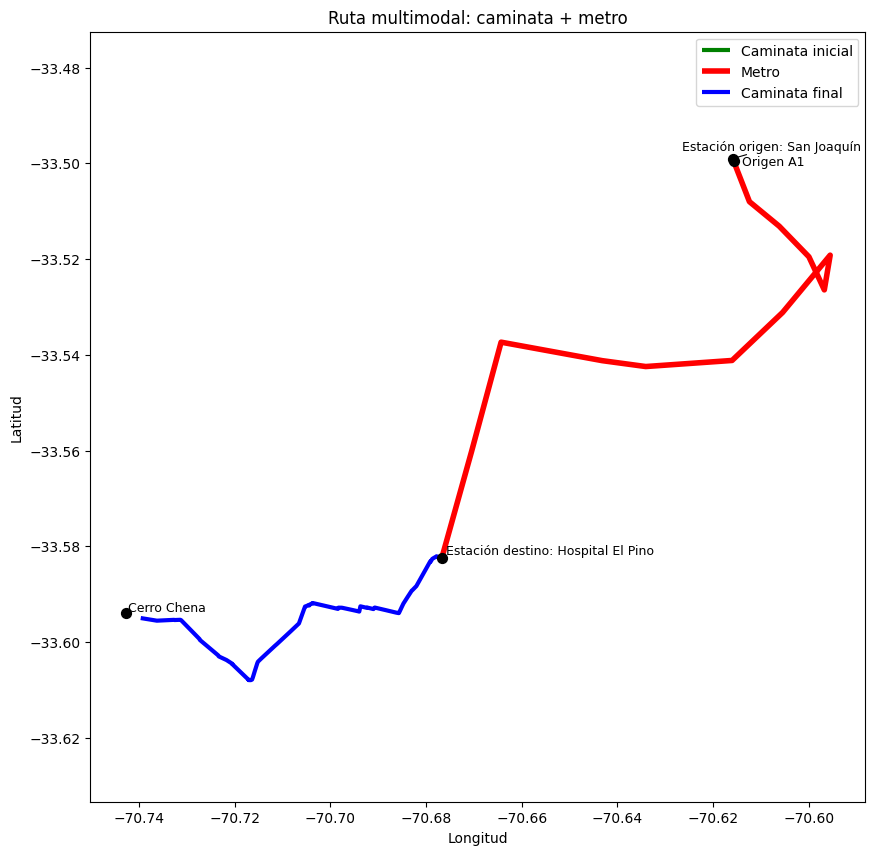

In [16]:
from adjustText import adjust_text

geom_walk_1 = ruta_a_geoseries(G_walk_origen, ruta_walk_1)
geom_walk_2 = ruta_a_geoseries(G_walk_destino, ruta_walk_2)

puntos_principales = gpd.GeoDataFrame(
    {
        "nombre": [
            "Origen A1",
            f"Estación origen: {est_origen['NOMBRE']}",
            f"Estación destino: {est_destino['NOMBRE']}",
            "Cerro Chena"
        ]
    },
    geometry=[
        Point(origen_a1[1], origen_a1[0]),
        est_origen.geometry,
        est_destino.geometry,
        Point(destino_chena[1], destino_chena[0])
    ],
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(10, 10))

geom_walk_1.plot(
    ax=ax,
    color="green",
    linewidth=3,
    label="Caminata inicial"
)

geom_metro.plot(
    ax=ax,
    color="red",
    linewidth=4,
    label="Metro"
)

geom_walk_2.plot(
    ax=ax,
    color="blue",
    linewidth=3,
    label="Caminata final"
)

puntos_principales.plot(
    ax=ax,
    color="black",
    markersize=50,
    zorder=5
)

texts = []

for _, row in puntos_principales.iterrows():
    texts.append(
        ax.text(
            row.geometry.x,
            row.geometry.y,
            row["nombre"],
            fontsize=9,
            zorder=6
        )
    )

adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(
        arrowstyle="-",
        lw=0.8
    )
)

plt.title("Ruta multimodal: caminata + metro")
plt.legend()
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.axis("equal")
plt.show()